In [5]:
!pip install -q spectral einops thop

import os, time, zipfile, gc
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import tensorflow as tf
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score, precision_recall_fscore_support
from tensorflow.keras.utils import to_categorical
import spectral

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# ===============================================================
# CONFIG (same style as LhSSN)
# ==============================================================

dataset = 'IP'
windowSize = 25
K = 30
epochs = 100
batch_size = 256
learning_rate = 0.001

split_mode = "ratio"          # ratio / count

train_ratio = 0.05           # if ratio
samples_per_class = 15       # if count

results_folder = "LhSSN_SA_Module_Output"
os.makedirs(results_folder, exist_ok=True)

base = "/content/drive/MyDrive/Colab Notebooks/dataset/"

# ===============================================================
# DATA LOADING
# ==============================================================

def loadData(name):
    if name == 'IP':
        data = sio.loadmat(base+'Indian_pines_corrected.mat')['indian_pines_corrected']
        labels = sio.loadmat(base+'Indian_pines_gt.mat')['indian_pines_gt']
    return data, labels

# ===============================================================
# PCA
# ==============================================================

def applyPCA(X, numComponents):
    reshaped = X.reshape(-1, X.shape[2])
    pca = PCA(n_components=numComponents, whiten=True)
    Xp = pca.fit_transform(reshaped)
    return Xp.reshape(X.shape[0], X.shape[1], numComponents)

# ===============================================================
# PATCH EXTRACTION
# ==============================================================

def padWithZeros(X, margin):
    return np.pad(X, ((margin,margin),(margin,margin),(0,0)), mode='constant')

def createImageCubes(X, y, windowSize=25):
    margin = windowSize // 2
    zeroPaddedX = padWithZeros(X, margin)

    patches = []
    labels = []

    for r in range(margin, zeroPaddedX.shape[0]-margin):
        for c in range(margin, zeroPaddedX.shape[1]-margin):

            patch = zeroPaddedX[r-margin:r+margin+1,
                                c-margin:c+margin+1]

            label = y[r-margin, c-margin]

            if label > 0:
                patches.append(patch)
                labels.append(label-1)

    return np.array(patches), np.array(labels)

# ===============================================================
# SPLIT
# ==============================================================

def splitTrainTestSet(X, y):

    np.random.seed(42)

    train_idx = []
    test_idx = []

    for cls in np.unique(y):

        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)

        if split_mode == "ratio":
            n_train = max(1, int(len(idx)*train_ratio))
        else:
            n_train = min(samples_per_class, len(idx)-1)

        train_idx.extend(idx[:n_train])
        test_idx.extend(idx[n_train:])

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# ===============================================================
# LOAD DATA
# ==============================================================

X, y = loadData(dataset)
X = applyPCA(X, K)
X, y = createImageCubes(X, y, windowSize)

Xtrain, Xtest, ytrain, ytest = splitTrainTestSet(X, y)

num_classes = len(np.unique(y))

ytrain_cat = to_categorical(ytrain, num_classes)
ytest_cat = to_categorical(ytest, num_classes)

print("Train:", Xtrain.shape)
print("Test :", Xtest.shape)


Train: (505, 25, 25, 30)
Test : (9744, 25, 25, 30)


In [14]:
# ===============================================================
# MODELLhSSN with conv Channel Attention
# ==============================================================

from tensorflow.keras import layers, models
from einops.layers.tensorflow import Rearrange
# --------- Build Model (EXACT architecture you used) ---------
def build_model(S, L, num_classes):
    inp = tf.keras.layers.Input((S, S, L, 1))
    # Block 1
    x = tf.keras.layers.Conv3D(filters=8,  kernel_size=(3,3,7), activation='relu')(inp)
    # Block 2
    x = tf.keras.layers.Conv3D(filters=16, kernel_size=(3,3,5), activation='relu')(x)
    # Block 3
    x = tf.keras.layers.Conv3D(filters=32, kernel_size=(3,3,3), activation='relu')(x)
    # Block 4  (reshape to 2D convs)
    conv3d_shape = x.shape  # (None, H, W, D, C)
    x = tf.keras.layers.Reshape((conv3d_shape[1], conv3d_shape[2],
                                 conv3d_shape[3]*conv3d_shape[4]))(x)
    x = tf.keras.layers.Conv2D(filters=24,  kernel_size=(3,3), activation='relu')(x)


    # Block 5
    x = tf.keras.layers.Conv2D(filters=96,  kernel_size=(3,3), activation='relu')(x)
    ########################################################
    # Spatial Attention
    x1 = layers.BatchNormalization(name='BatchNormalization_4')(x)

    y1 = layers.MaxPooling2D((2, 2), padding="same", strides=(1, 1), name='MaxPooling2D_y1')(x1)
    y2 = layers.AvgPool2D((2, 2), padding="same", strides=(1, 1), name='AvgPool2D_y2')(x1)
    concat = layers.Concatenate()([y1, y2])

    y4 = layers.Conv2D(32, (3, 3), padding='valid', dilation_rate=2, name='Conv2D_y2')(concat)

    y4 = layers.BatchNormalization(name='BatchNormalization_y')(y4)
    #y4 = layers.ReLU()(y4)
    y4 = tf.keras.activations.gelu(y4)

    # Channel Attention
    # Skip Connection (M)
    #concat_m = layers.Concatenate()([y4, x1])
    z = layers.MaxPooling2D((2, 2), strides=(2, 2), name='MaxPooling2D_z')(y4)
    z = tf.keras.layers.GlobalAveragePooling2D()(z)

#################################################
    x = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x)
    # Block 6
    x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Block 7
    x = layers.Concatenate()([x, z])


    # Block 7
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    # Output Layer
    out = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.models.Model(inputs=inp, outputs=out)
    # Adam 0.001 as in your code
    model.compile(loss='categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  metrics=['accuracy'])
    return model

model = build_model(windowSize, K, num_classes)

# Save Summary
with open(results_folder+"/model_summary.txt","w") as f:
    model.summary(print_fn=lambda x: f.write(x+"\n"))

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 25, 25,    │          0 │ -                 │
│ (InputLayer)        │ 30, 1)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_12 (Conv3D)  │ (None, 23, 23,    │        512 │ input_layer_4[0]… │
│                     │ 24, 8)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_13 (Conv3D)  │ (None, 21, 21,    │      5,776 │ conv3d_12[0][0]   │
│                     │ 20, 16)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3d_14 (Conv3D)  │ (None, 19, 19,    │     13,856 │ conv3d_13[0][0]   │
│                     │ 18, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 19, 19,    │          0 │ conv3d_14[0][0]   │
│                     │ 576)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 17, 17,    │    124,440 │ reshape_4[0][0]   │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 15, 15,    │     20,832 │ conv2d_9[0][0]    │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNormalization… │ (None, 15, 15,    │        384 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPooling2D_y1     │ (None, 15, 15,    │          0 │ BatchNormalizati… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ AvgPool2D_y2        │ (None, 15, 15,    │          0 │ BatchNormalizati… │
│ (AveragePooling2D)  │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 15, 15,    │          0 │ MaxPooling2D_y1[… │
│ (Concatenate)       │ 192)              │            │ AvgPool2D_y2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv2D_y2 (Conv2D)  │ (None, 11, 11,    │     55,328 │ concatenate_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BatchNormalization… │ (None, 11, 11,    │        128 │ Conv2D_y2[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 7, 7, 96)  │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu (Gelu)         │ (None, 11, 11,    │          0 │ BatchNormalizati… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 5, 5, 128) │    110,720 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPooling2D_z      │ (None, 5, 5, 32)  │          0 │ gelu[0][0]        │
│ (MaxPooling2D)      │                   │            │                 

 Total params: 361,880 (1.38 MB)

 Trainable params: 361,624 (1.38 MB)

 Non-trainable params: 256 (1.00 KB)

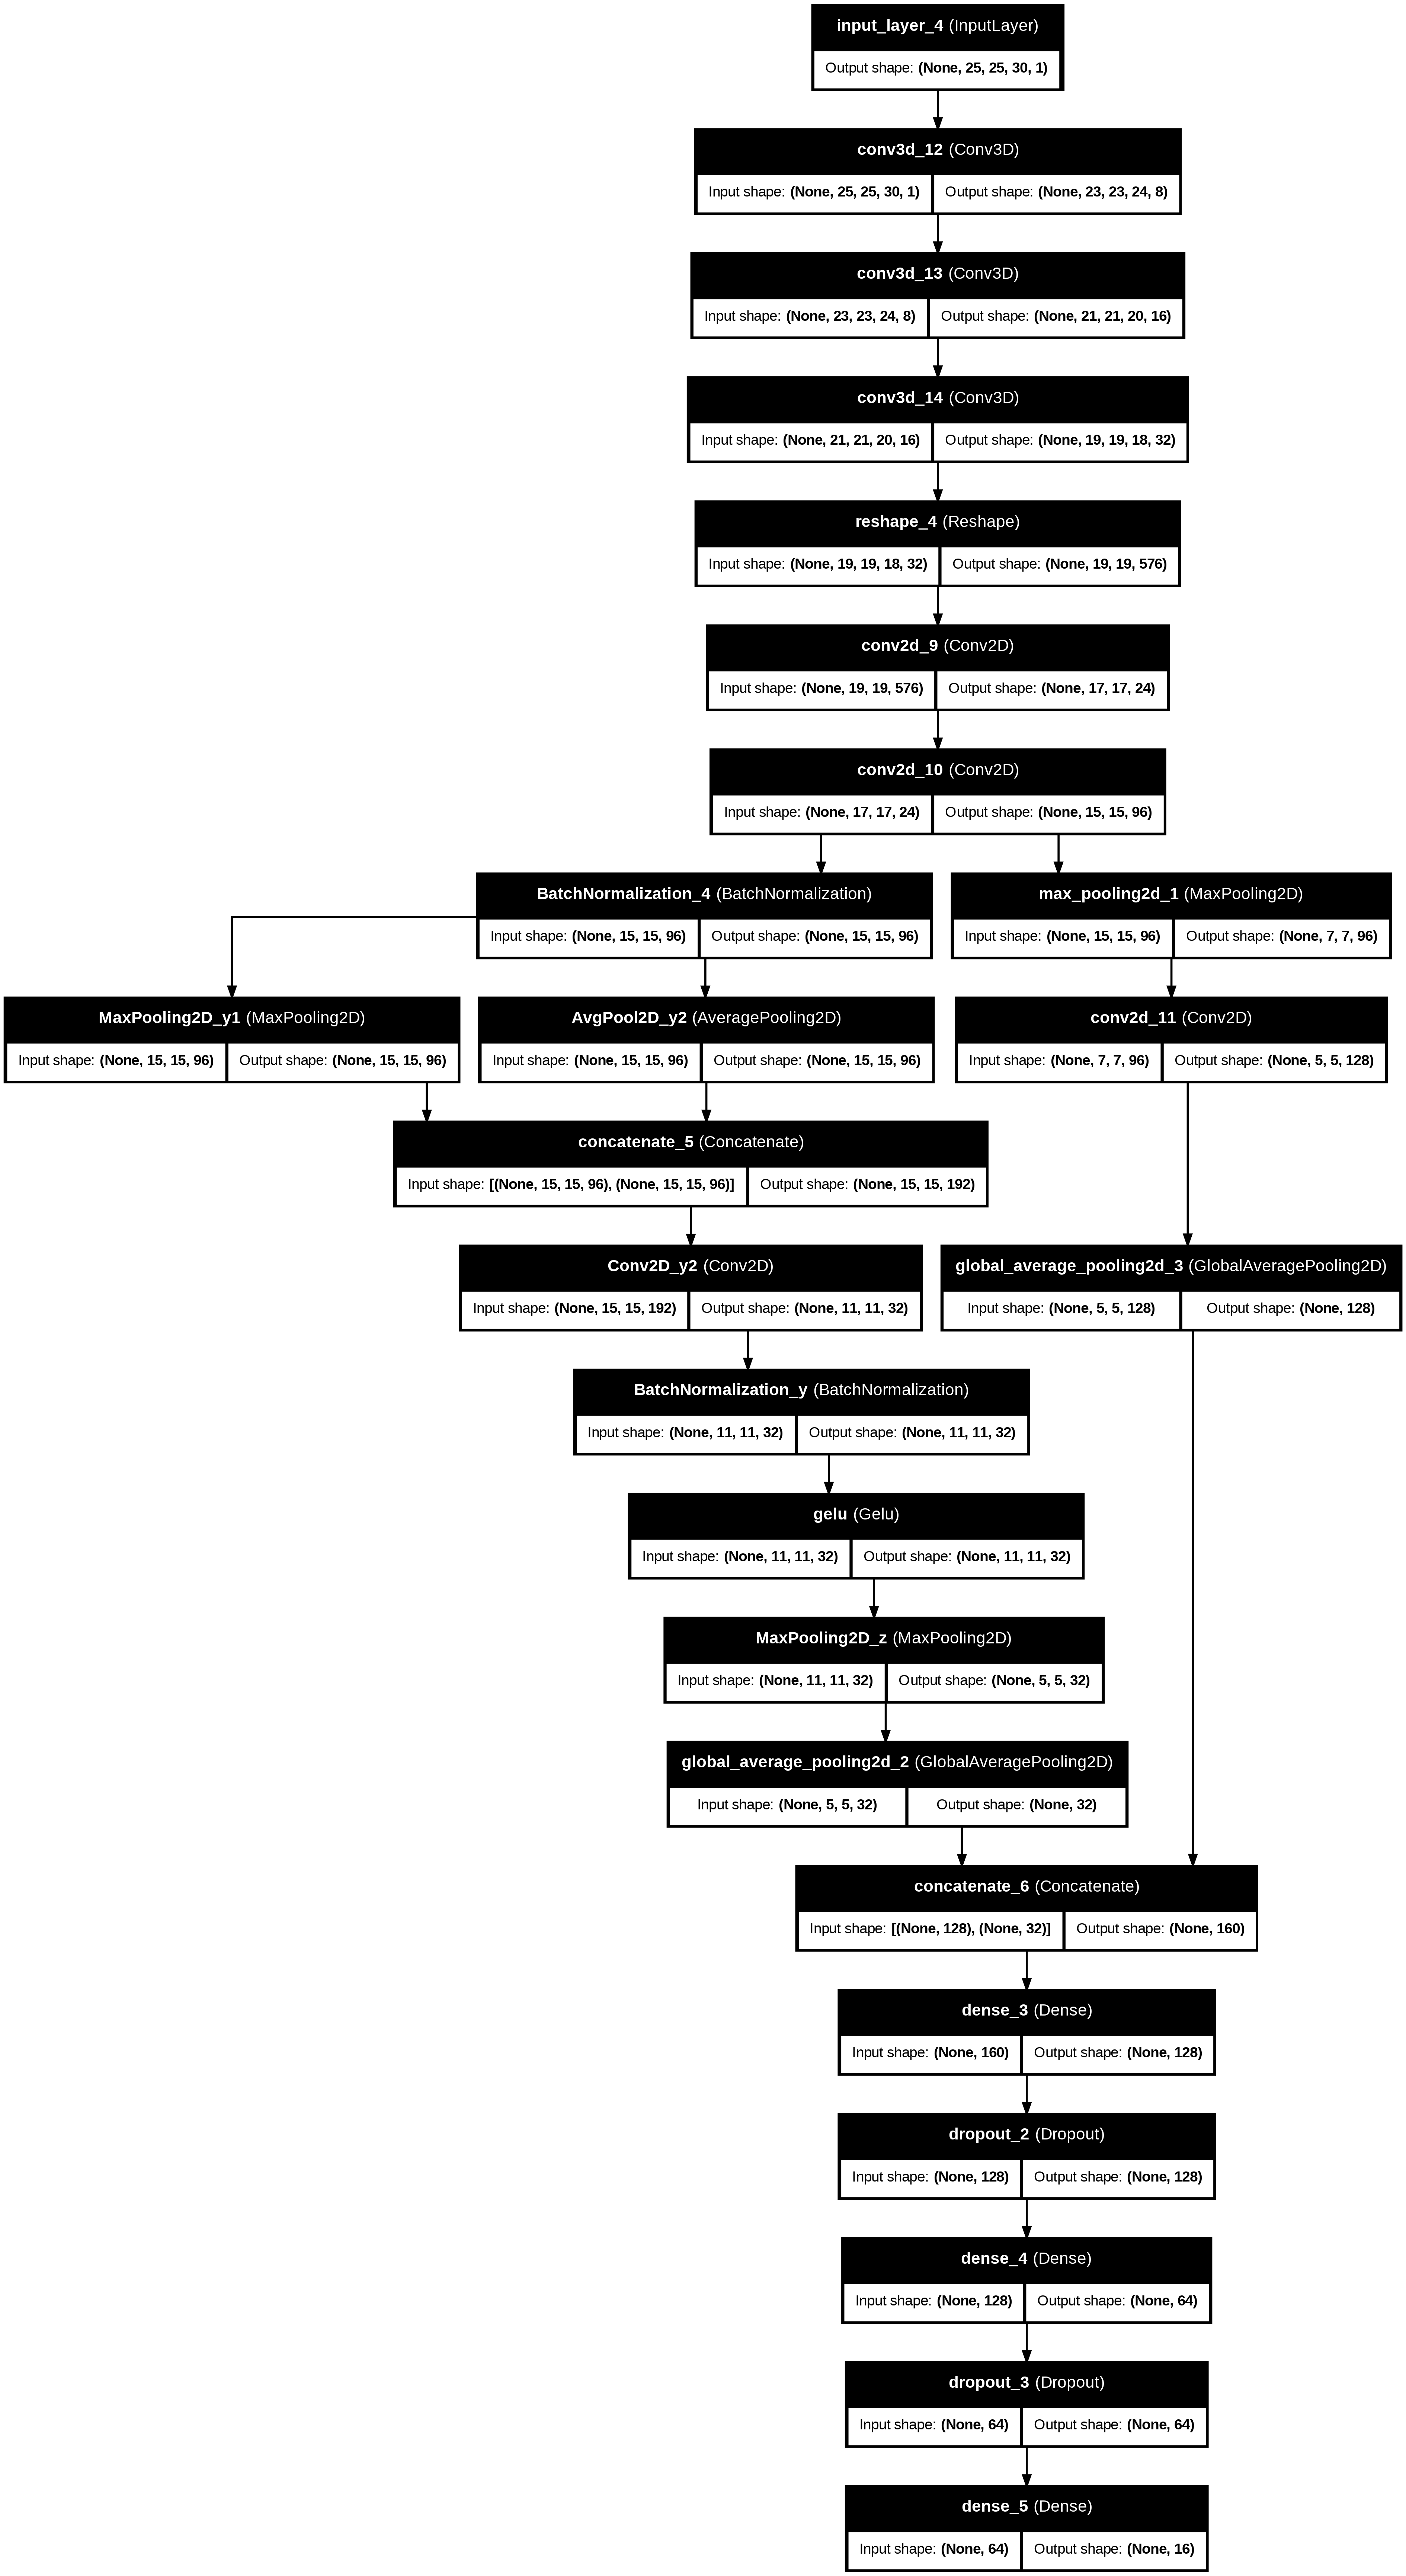

In [15]:
#from tensorflow.keras.utils import plot_model
from keras.utils import plot_model, to_categorical
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Epoch 1/100
2/2 - 23s - 11s/step - accuracy: 0.0535 - loss: 2.9818 - val_accuracy: 0.0053 - val_loss: 2.7517
Epoch 2/100
2/2 - 4s - 2s/step - accuracy: 0.1426 - loss: 2.6414 - val_accuracy: 0.2845 - val_loss: 2.6397
Epoch 3/100
2/2 - 4s - 2s/step - accuracy: 0.2693 - loss: 2.4335 - val_accuracy: 0.3639 - val_loss: 2.5176
Epoch 4/100
2/2 - 3s - 2s/step - accuracy: 0.3307 - loss: 2.2741 - val_accuracy: 0.3957 - val_loss: 2.4621
Epoch 5/100
2/2 - 3s - 2s/step - accuracy: 0.3564 - loss: 2.1333 - val_accuracy: 0.3993 - val_loss: 2.3560
Epoch 6/100
2/2 - 4s - 2s/step - accuracy: 0.3663 - loss: 2.0571 - val_accuracy: 0.4076 - val_loss: 2.3010
Epoch 7/100
2/2 - 3s - 2s/step - accuracy: 0.4119 - loss: 1.9600 - val_accuracy: 0.4246 - val_loss: 2.2245
Epoch 8/100
2/2 - 3s - 2s/step - accuracy: 0.4297 - loss: 1.7944 - val_accuracy: 0.4624 - val_loss: 2.1040
Epoch 9/100
2/2 - 3s - 2s/step - accuracy: 0.5109 - loss: 1.6827 - val_accuracy: 0.4985 - val_loss: 1.9193
Epoch 10/100
2/2 - 3s - 2s/step - a

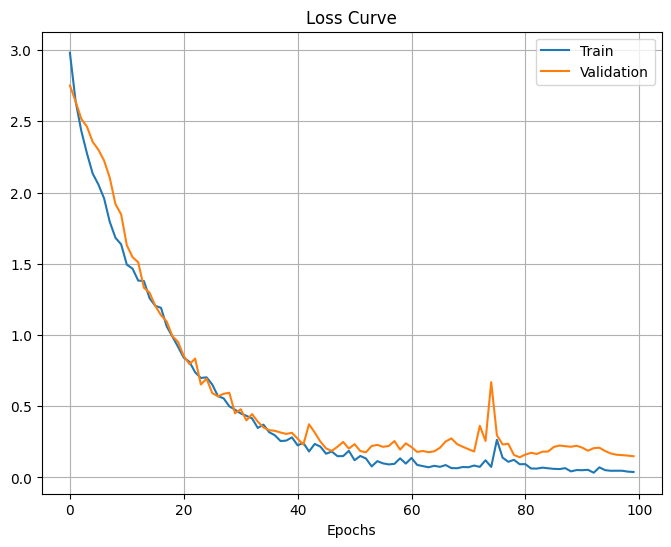

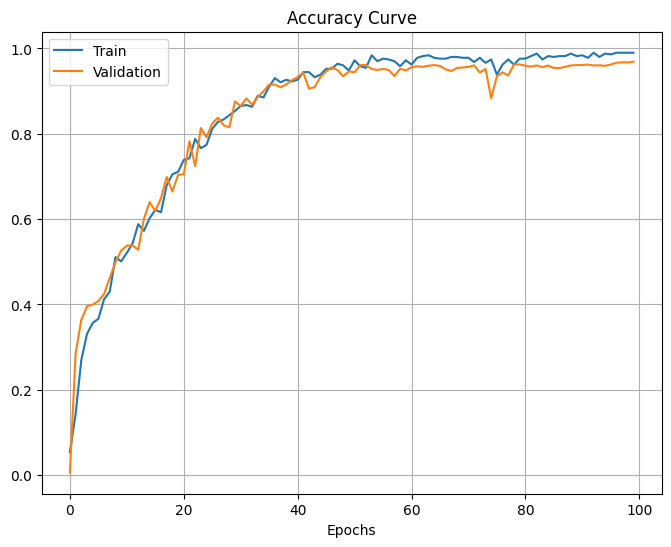

305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step
DONE.
ZIP FILE: LhSSN_SA_Module_Output.zip


In [16]:
import time

# ===============================================================
# TRAIN
# ==============================================================

tic = time.time()

history = model.fit(
    Xtrain, ytrain_cat,
    validation_data=(Xtest, ytest_cat),
    epochs=epochs,
    batch_size=batch_size,
    verbose=2
)

toc = time.time()

train_time = toc - tic

# Save history
np.save(results_folder+"/history.npy", history.history)

# ===============================================================
# PLOTS
# ==============================================================

def save_plot(a,b,title,name):

    plt.figure(figsize=(8,6))
    plt.plot(history.history[a], label='Train')
    plt.plot(history.history[b], label='Validation')
    plt.xlabel("Epochs")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.savefig(results_folder+"/"+name+".png", dpi=300)
    plt.show()

save_plot("loss","val_loss","Loss Curve","loss_curve")
save_plot("accuracy","val_accuracy","Accuracy Curve","accuracy_curve")

# ===============================================================
# EVALUATION
# ==============================================================

tic = time.time()

pred = model.predict(Xtest)

toc = time.time()

test_time = toc - tic

y_pred = np.argmax(pred, axis=1)

oa = accuracy_score(ytest, y_pred)
kappa = cohen_kappa_score(ytest, y_pred)

cm = confusion_matrix(ytest, y_pred)

each_acc = np.diag(cm)/cm.sum(axis=1)
aa = np.mean(each_acc)

precision, recall, f1, _ = precision_recall_fscore_support(
    ytest, y_pred, average='weighted'
)

# ===============================================================
# SAVE REPORT
# ==============================================================

with open(results_folder+"/results.txt","w") as f:

    f.write(f"Training Time: {train_time:.2f}s\n")
    f.write(f"Testing Time: {test_time:.2f}s\n")
    f.write(f"OA: {oa*100:.2f}\n")
    f.write(f"AA: {aa*100:.2f}\n")
    f.write(f"Kappa: {kappa*100:.2f}\n")
    f.write(f"Precision: {precision*100:.2f}\n")
    f.write(f"Recall: {recall*100:.2f}\n")
    f.write(f"F1-score: {f1*100:.2f}\n\n")

    f.write(classification_report(ytest, y_pred))

# ===============================================================
# CLASSIFICATION MAP
# ==============================================================

Xfull, yfull = loadData(dataset)
Xfull = applyPCA(Xfull, K)

margin = windowSize//2
Xpad = padWithZeros(Xfull, margin)

outputs = np.zeros(yfull.shape)

patches = []
coords = []

for i in range(yfull.shape[0]):
    for j in range(yfull.shape[1]):

        if yfull[i,j] > 0:

            patch = Xpad[i:i+windowSize, j:j+windowSize]
            patches.append(patch)
            coords.append((i,j))

patches = np.array(patches)

pred = model.predict(patches, batch_size=512)
pred = np.argmax(pred, axis=1)

for (i,j),p in zip(coords,pred):
    outputs[i,j] = p+1

spectral.save_rgb(
    results_folder+"/classified_map.jpg",
    outputs.astype(int),
    colors=spectral.spy_colors
)

spectral.save_rgb(
    results_folder+"/ground_truth.jpg",
    yfull.astype(int),
    colors=spectral.spy_colors
)

# ===============================================================
# ZIP
# ==============================================================

zip_name = "LhSSN_SA_Module_Output.zip"

with zipfile.ZipFile(zip_name,'w') as zipf:
    for file in os.listdir(results_folder):
        zipf.write(results_folder+"/"+file, arcname=file)

print("DONE.")
print("ZIP FILE:", zip_name)